Let's start with a real qubit error 

In [41]:
pip install qiskit qiskit-ibm-runtime



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler

In [43]:
# import json

# # 读取JSON文件
# with open(r'D:\Quantum_studies\apikey.json', 'r') as f:
#     data = json.load(f)


# API_KEY = data['apikey']

# from qiskit_ibm_runtime import QiskitRuntimeService
 
# QiskitRuntimeService.save_account(
#     token=API_KEY, # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
#     instance="crn:v1:bluemix:public:quantum-computing:us-east:a/9b8bc3164f694c90b9e3e2b8be87175a:cf79926b-2b20-403b-9a23-d4aaf23cfbd7::", # Optional
#     overwrite=True
#     )

# # Every time you need the service

# from qiskit_ibm_runtime import QiskitRuntimeService

# # Run every time you need the service
# service = QiskitRuntimeService()


In [44]:
# backend = service.least_busy(operational=True, simulator=False) 

In [45]:
# from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
# from qiskit_ibm_runtime import QiskitRuntimeService
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# # =====================================================================
# # 构建你的主动纠错量子电路 (Active QEC Circuit)
# # =====================================================================
# q = QuantumRegister(5, 'q')
# # c_syn = ClassicalRegister(2, 'syndrome') # 存储中途测出来的错误信号
# c_out = ClassicalRegister(1, 'output')   # 最终读取结果

# qc = QuantumCircuit(q, c_syn, c_out)

# # --------------- 编码阶段 (Encoding) ---------------
# qc.x(q[0]) # 把 q[0] 变成 |1>，我们要保护它
# qc.cx(q[0], q[1])
# qc.cx(q[0], q[2])
# qc.barrier()

# # --------------- 错误发生阶段 (Error) ---------------
# # 故意翻转 q[0]，模拟一个比特翻转错误
# qc.x(q[0]) 
# qc.barrier()

# # --------------- 错误检测阶段 (Syndrome Measurement) ---------------
# qc.cx(q[0], q[3])
# qc.cx(q[1], q[3]) 
# qc.cx(q[1], q[4])
# qc.cx(q[2], q[4]) 

# # 【中途测量】：这是 IBM 硬件的黑科技，在电路运行中间测出 0 和 1
# qc.measure(q[3], c_syn[0])
# qc.measure(q[4], c_syn[1])
# qc.barrier()

# # --------------- 实时主动纠错阶段 (Feed-forward) ---------------
# # 根据中途测量测出的 Syndrome 进行实时的硬件级修正
# with qc.if_test((c_syn, 1)):   # 如果 syndrome 是 01
#     qc.x(q[0])                 # 当场修复 q[0]
# with qc.if_test((c_syn, 2)):   # 如果 syndrome 是 10
#     qc.x(q[2])                 # 当场修复 q[2]
# with qc.if_test((c_syn, 3)):   # 如果 syndrome 是 11
#     qc.x(q[1])                 # 当场修复 q[1]
# qc.barrier()

# # --------------- 最终检验 ---------------
# qc.measure(q[0], c_out[0])


# # =====================================================================
# # 编译并发送到真实硬件 (兼容 Open Plan 免费账户的 V2 写法)
# # =====================================================================

# # 2. 编译电路 (ISA - Instruction Set Architecture)
# # 这一步必须做！它会将你写的理想逻辑门，翻译成这台机器真实支持的物理门和拓扑结构
# print("正在将电路编译至目标硬件架构...")
# pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
# isa_qc = pm.run(qc)

# # 3. 初始化 SamplerV2 (不使用 Session，使用 mode=backend 模式)
# sampler = Sampler(mode=backend)
# # 设置运行次数 (shots)
# sampler.options.default_shots = 1000

# # 4. 提交任务到真机
# print(f"正在向真机 {backend.name} 提交任务...")
# # 注意：V2 版本的 run() 必须传入一个列表，即使只有一个电路
# job = sampler.run([isa_qc]) 
# print(f"提交成功！Job ID: {job.job_id()}")
# print("你可以在 Dashboard 查看进度: https://quantum.cloud.ibm.com/jobs")

# # 5. 等待并解析结果
# print("正在等待真机运行结果（可能需要排队，请耐心等待）...")
# result = job.result()
# pub_result = result[0]

# # 在 V2 版本中，不同寄存器的结果被分开存储了，提取非常方便
# print("\n========== 真机运行结果 ==========")
# print("最终保护结果 (Output register):", pub_result.data.output.get_counts())
# print("中途捕捉到的错误信号 (Syndrome register):", pub_result.data.syndrome.get_counts())

In [46]:
# qc.draw(output='mpl')   

# Simulator 

In [47]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit import transpile


noise_model = NoiseModel()

# 单比特门的 depolarizing 噪声
single_qubit_error = depolarizing_error(0.1, 1)  # 0.1% 错误率
two_qubit_error = depolarizing_error(0.1, 2)      # 1% 错误率

noise_model.add_all_qubit_quantum_error(single_qubit_error, ['x', 'h', 'sx', 'rz'])
noise_model.add_all_qubit_quantum_error(two_qubit_error, ['cx'])

# 2. 创建带这个噪声模型的本地模拟器
sim = AerSimulator(noise_model=noise_model)


q = QuantumRegister(5, 'q')
c_syn = ClassicalRegister(2, 'syndrome') # 存储中途测出来的错误信号
c_out = ClassicalRegister(1, 'output')   # 最终读取结果

qc = QuantumCircuit(q, c_syn, c_out)

为了对量子bit 进行保护

怕一个比特 1 因为干扰变成 0，最简单的办法就是把它存三遍

初始状态：默认所有量子比特都是 $\ket{0}$, 状态为  $\ket{000}$

我们使用CX 也就是 CNOT 门，根据前半部分作为observe 改变后半部分

比如 当观察前部分 为 $\ket{0}$ 后半部分不变, 观察前部分 为 $\ket{1}$ 后半部分反转 

In [48]:
# --------------- 编码阶段 (Encoding) ---------------
qc.x(q[0]) # 把 q[0] 变成 |1>，我们要保护它
qc.cx(q[0], q[1])
qc.cx(q[0], q[2])

qc.save_statevector(label='repitition_code') # 记录第一个节点


qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

现在我们假设错误发生 

In [49]:
# --------------- 错误发生阶段 (Error) ---------------
# 故意翻转 q[0]，模拟一个比特翻转错误
qc.x(q[0]) 

qc.save_statevector(label='after_error') # 记录第二个节点

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

现在 我们加入辅助qubit用来查看错误情况 

In [50]:
# --------------- 错误检测阶段 (Syndrome Measurement) ---------------
qc.cx(q[0], q[3])
qc.cx(q[1], q[3]) 
qc.cx(q[1], q[4])
qc.cx(q[2], q[4]) 

qc.save_statevector(label='after_syndrome') # 记录第三个节点

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

In [51]:
# 【中途测量】：这是 IBM 硬件的黑科技，在电路运行中间测出 0 和 1
qc.measure(q[3], c_syn[0])
qc.measure(q[4], c_syn[1])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

In [52]:
# --------------- 实时主动纠错阶段 (Feed-forward) ---------------
# 根据中途测量测出的 Syndrome 进行实时的硬件级修正
with qc.if_test((c_syn, 1)):   # 如果 syndrome 是 01
    qc.x(q[0])                 # 当场修复 q[0]
with qc.if_test((c_syn, 2)):   # 如果 syndrome 是 10
    qc.x(q[2])                 # 当场修复 q[2]
with qc.if_test((c_syn, 3)):   # 如果 syndrome 是 11
    qc.x(q[1])                 # 当场修复 q[1]
qc.barrier()

# --------------- 最终检验 ---------------
qc.measure(q[0], c_out[0])

# 2. 把电路编译到这个模拟器
compiled_qc = transpile(qc, sim)

# 3. 在本地模拟器上运行
job = sim.run(compiled_qc, shots=1000)
result = job.result()

# 4. 拿到所有经典比特的测量统计
counts = result.get_counts()

print("全部经典寄存器测量结果:", counts)

全部经典寄存器测量结果: {'1 01': 554, '0 10': 46, '0 11': 111, '1 11': 17, '0 01': 84, '1 00': 88, '1 10': 56, '0 00': 44}


In [53]:
from qiskit.quantum_info import Statevector

# 拿到 statevector 对象
sv = result.data(qc)['after_error']   # 你现在这行拿到的就是它

# 看“单独测量第 0 个 qubit（最右边那个）时 0/1 的概率”
probs_q0 = sv.probabilities_dict(qargs=[0])
print("第 0 个 qubit 的 0/1 概率:", probs_q0)
probs_q1 = sv.probabilities_dict(qargs=[1])
print("第 1 个 qubit 的 0/1 概率:", probs_q1)
probs_q2 = sv.probabilities_dict(qargs=[2])
print("第 2 个 qubit 的 0/1 概率:", probs_q2)
# 如果你想看第 1 个 qubit，就写 qargs=[1]，以此类推


第 0 个 qubit 的 0/1 概率: {np.str_('0'): np.float64(1.0)}
第 1 个 qubit 的 0/1 概率: {np.str_('1'): np.float64(1.0)}
第 2 个 qubit 的 0/1 概率: {np.str_('1'): np.float64(1.0)}


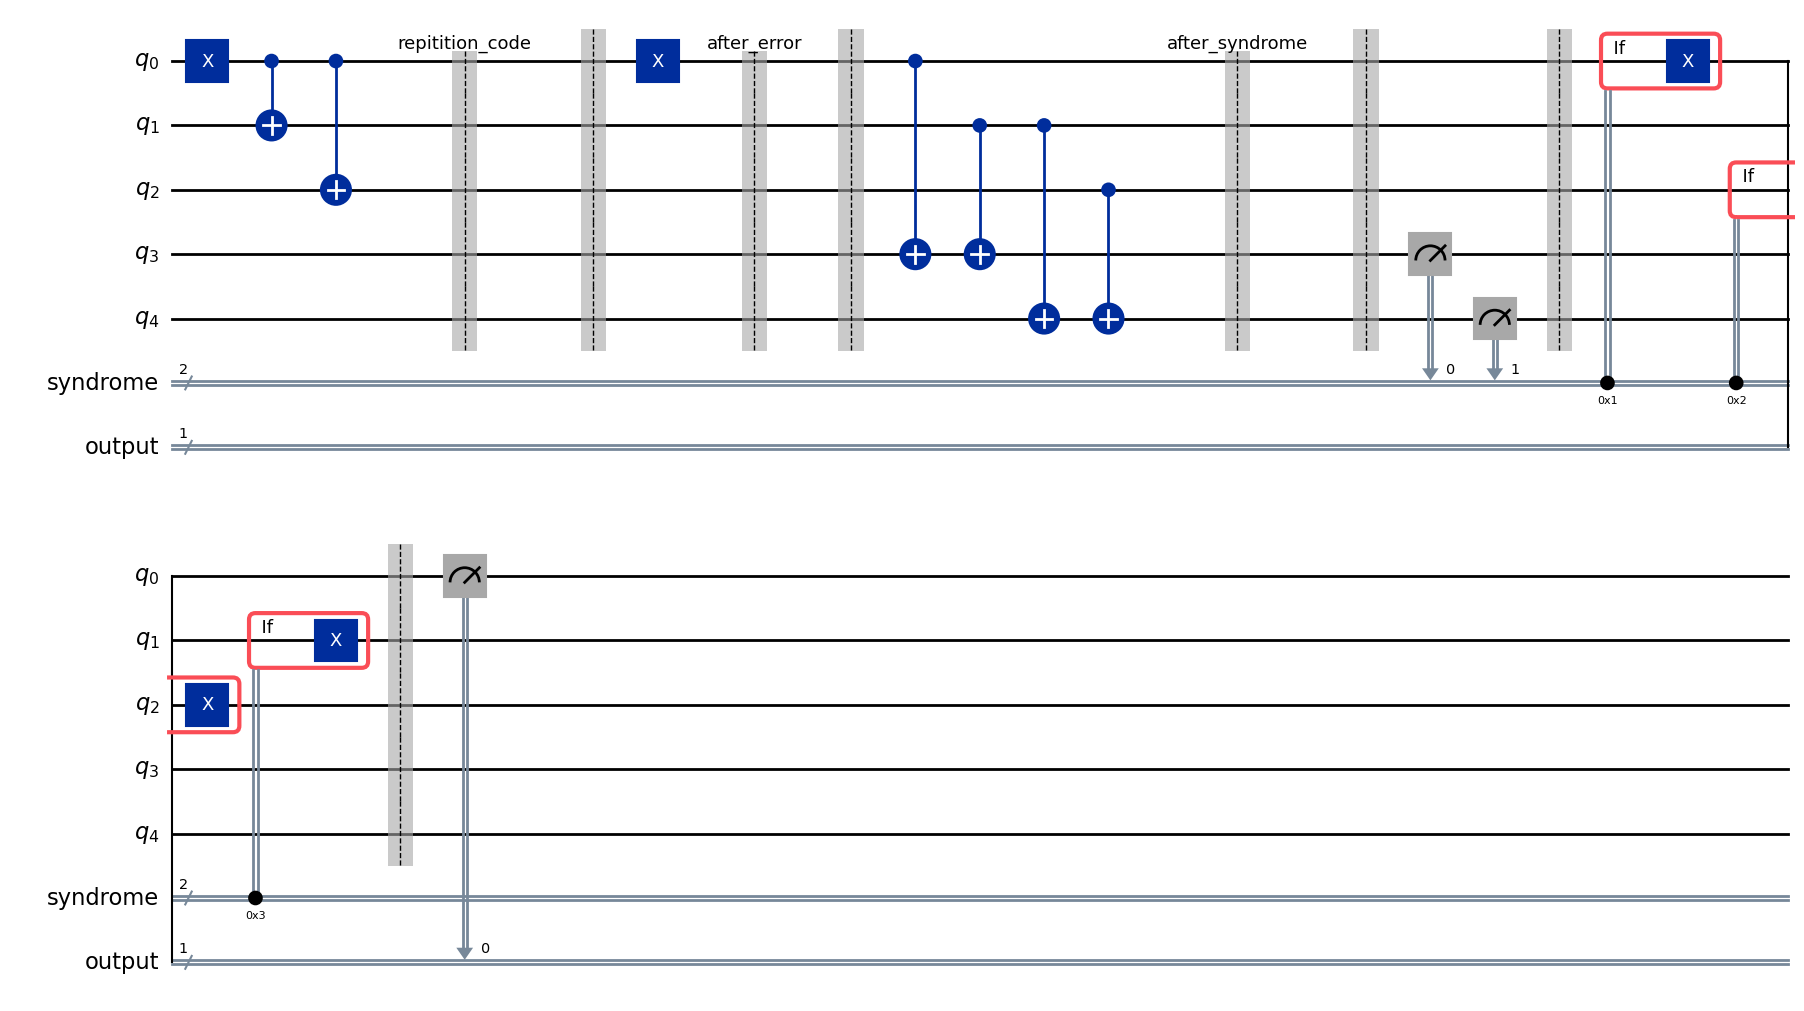

In [54]:
qc.draw(output='mpl')

## 🚀 进阶挑战一：定量分析——寻找“纠错阈值” (Threshold)

> **问题背景**：纠错操作本身（额外的门和比特）也会引入噪声。如果物理错误率太高，纠错引入的噪声反而会超过它修复的部分。

| 维度 | 内容说明 |
| :--- | :--- |
| **挑战任务** | 编写脚本自动化运行，将噪声参数 `p` 从 0.001 逐渐增加到 0.1。 |
| **对比实验** | 同时监控两个电路：1. 物理比特执行 X 门；2. 逻辑比特执行逻辑 X 门（含完整纠错流程）。 |
| **核心指标** | 绘制 “物理错误率 vs. 逻辑错误率” 曲线，寻找两条线的交叉点（即阈值）。 |
| **思考点** | 在你的硬件噪声模型下，物理错误率达到多少时，纠错反而会让结果变差？ |



## 🚀 进阶挑战二：应对相位错误——相位翻转码 (Phase-Flip)

> **问题背景**：量子比特不仅会发生比特翻转 (X 错误)，还会发生相位翻转 (Z 错误)，即让 |+⟩ 变成 |-⟩。目前的电路对此无法检测。



| 维度 | 内容说明 |
| :--- | :--- |
| **挑战任务** | 修改现有电路，使其能够检测并修复 Z 轴相位错误。 |
| **实现提示** | 在编码 (Encoding) 和检测 (Syndrome) 的前后各加一层 Hadamard (H) 门。 |
| **学习重点** | **基底变换 (Basis Change)**：理解如何利用 H 门将 Z 错误转化为 X 错误来处理 ($HZH=X$)。 |



## 🚀 进阶挑战三：全能型编码——9-Qubit Shor 码

> **问题背景**：比特翻转码只能防 X，相位码只能防 Z。Shor 码通过“嵌套”两者，实现了对单比特任意量子错误的全面保护。



| 维度 | 内容说明 |
| :--- | :--- |
| **挑战任务** | 实现 Peter Shor 在 1995 年提出的 9 比特编码电路。 |
| **架构逻辑** | 采用嵌套结构：外层 3 比特块防相位错误，内层每个块内的 3 比特防比特翻转。 |
| **学习重点** | **嵌套编码 (Concatenated Codes)**：学习如何通过多层级结构构建更高保真度的逻辑比特。 |



## 🚀 进阶挑战四：逻辑门操作 (Logical Gates)

> **问题背景**：保护住比特只是开始，我们最终要在“不解密（不回退到物理比特）”的情况下对逻辑比特进行运算。

| 维度 | 内容说明 |
| :--- | :--- |
| **挑战任务** | 在不破坏编码结构的前提下，给逻辑比特施加一个“逻辑 X 门”。 |
| **操作思考** | 要实现逻辑上的 $|0\rangle_L \to |1\rangle_L$，是对 $q[0]$ 做 X 门，还是对 $q[0,1,2]$ 同时做 X 门？ |
| **深层概念** | **横向门 (Transversal Gates)**：探索哪些操作可以天然地在多个物理比特上并行执行而不扩散错误。 |